# COMP8325 — Task 1: Model Training & Comparison

This notebook loads LIEF/Ember-style features from `bodmas.npz`, aligns rows with
`bodmas_metadata.csv`, and assigns **malware category** labels from
`bodmas_malware_category.csv`. Benign samples (`y=0`) are labelled **benign**.

**Models compared:** (1) Random Forest, (2) HistGradientBoostingClassifier.

**Metrics:** overall accuracy; per-class TPR (recall) and FPR (one-vs-rest).

| Rubric area | Where addressed |
|---|---|
| Data loading & labels | Section 2 |
| Preprocessing & features | Section 4 |
| Train/test split | Section 3 |
| Hyperparameter tuning | Sections 6, 8, 9 |
| Evaluation | Sections 5, 10, 11 |
| Reproducibility | Section 1 |

## 1. Configuration and imports

In [1]:
from __future__ import annotations
import json
import sys
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    StratifiedShuffleSplit,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
import sklearn

# Data directory — adjust if your layout differs

NPZ_PATH  = "data/bodmas.npz"
META_PATH = "data/bodmas_metadata.csv"
CAT_PATH  = "data/bodmas_malware_category.csv"

# Reproducibility
RANDOM_STATE            = 42
TEST_SIZE               = 0.2
TUNE_SUBSAMPLE_FRACTION = 0.25
TUNE_RANDOM_STATE       = 42

# Random Forest speed knobs
RF_MAX_SAMPLES    = 0.20
RF_SEARCH_N_ITER  = 4
RF_MAX_LEAF_NODES = 384
RF_FIT_TRAIN_ROWS = 30_000

# HistGradientBoosting speed knobs
HGB_MAX_BINS       = 64
HGB_FIT_TRAIN_ROWS = 35_000

print(f"Python: {sys.version.split()[0]} | scikit-learn: {sklearn.__version__}")

Python: 3.13.9 | scikit-learn: 1.7.2


## 2. Load features and build multiclass labels

In [2]:
raw      = np.load(NPZ_PATH)
X        = raw["X"]
y_binary = raw["y"]

meta = pd.read_csv(META_PATH)
cats = pd.read_csv(CAT_PATH)

if "sha" in meta.columns and "sha256" not in meta.columns:
    meta = meta.rename(columns={"sha": "sha256"})

merged = meta.merge(cats, on="sha256", how="left")

y_category = np.where(
    y_binary == 0,
    "benign",
    merged["category"].astype(str).values,
)

print(f"X shape: {X.shape}")
print("Class counts:")
print(pd.Series(y_category).value_counts())

X shape: (134435, 2381)
Class counts:
benign                77142
trojan                29972
worm                  16697
backdoor               7331
downloader             1031
ransomware              821
dropper                 715
informationstealer      448
virus                   192
pua                      29
cryptominer              20
p2p-worm                 16
exploit                  12
trojan-gamethief          6
rootkit                   3
Name: count, dtype: int64


## 3. Encode labels and stratified train/test split

In [3]:
le = LabelEncoder()
y  = le.fit_transform(y_category)
class_names = le.classes_.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

## 4. Feature preprocessing (train-fit only)

1. `SimpleImputer(strategy="median")` — fit on train only, then applied to both splits.
2. `VarianceThreshold(0)` — drops zero-variance columns fitted on train only.

No scaling is applied; tree ensembles are invariant to monotone feature transforms.

In [4]:
def safe_preprocess(X_train_raw, X_test_raw):
    imputer = SimpleImputer(strategy="median")
    X_train_imp = imputer.fit_transform(X_train_raw)
    X_test_imp  = imputer.transform(X_test_raw)
    selector = VarianceThreshold(threshold=0.0)
    X_train_proc = selector.fit_transform(X_train_imp)
    X_test_proc  = selector.transform(X_test_imp)
    return X_train_proc, X_test_proc, imputer, selector


X_train, X_test, imputer, variance_selector = safe_preprocess(X_train, X_test)
print(f"Features reduced: {X.shape[1]} -> {X_train.shape[1]}")

Features reduced: 2381 -> 2331


## 5. Per-class TPR / FPR helpers

In [5]:
def per_class_tpr_fpr(y_true, y_pred, labels):
    cm  = confusion_matrix(y_true, y_pred, labels=labels)
    tpr, fpr = [], []
    n = cm.sum()
    for k in range(len(labels)):
        tp = cm[k, k]
        fn = cm[k, :].sum() - tp
        fp = cm[:, k].sum() - tp
        tn = n - tp - fn - fp
        tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    return np.array(tpr), np.array(fpr)


def metrics_report(name, y_true, y_pred, label_names):
    labels_idx = np.arange(len(label_names))
    acc        = accuracy_score(y_true, y_pred)
    tpr, fpr   = per_class_tpr_fpr(y_true, y_pred, labels_idx)
    print(f"\n=== {name} ===")
    print(f"Overall accuracy: {acc:.4f}")
    df = pd.DataFrame({
        "class":        label_names,
        "TPR (recall)": tpr,
        "FPR":          fpr,
    })
    pd.set_option("display.max_rows", None)
    print(df.to_string(index=False))
    print("\nClassification report:")
    print(classification_report(
        y_true, y_pred,
        target_names=label_names,
        digits=4,
        zero_division=0,
    ))
    return acc, df

## 6. Tuning subsample (training data only)

In [6]:
def stratified_subsample_indices(y_array, fraction, seed, min_per_class=3):
    """Stratified subsample so rare classes keep enough rows for k-fold CV."""
    if fraction >= 1.0:
        return np.arange(len(y_array))
    rng = np.random.default_rng(seed)
    idx = []
    for c in np.unique(y_array):
        c_idx  = np.flatnonzero(y_array == c)
        n_frac = int(np.ceil(len(c_idx) * fraction))
        n_take = min(len(c_idx), max(n_frac, min(min_per_class, len(c_idx))))
        idx.append(rng.choice(c_idx, size=n_take, replace=False))
    return np.concatenate(idx)


tune_idx = stratified_subsample_indices(
    y_train, TUNE_SUBSAMPLE_FRACTION, TUNE_RANDOM_STATE
)
X_tune = X_train[tune_idx]
y_tune = y_train[tune_idx]

counts_tune    = np.bincount(y_tune, minlength=len(class_names))
min_class_tune = int(counts_tune.min())

if min_class_tune >= 3:
    cv_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
elif min_class_tune == 2:
    cv_tuning = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
else:
    cv_tuning = StratifiedShuffleSplit(
        n_splits=5, test_size=0.25, random_state=RANDOM_STATE,
    )
    print("Note: using StratifiedShuffleSplit — document this in report.")

print("Tuning set size:", X_tune.shape[0],
      "| CV:", cv_tuning,
      "| min class count:", min_class_tune)

Tuning set size: 26897 | CV: StratifiedKFold(n_splits=2, random_state=42, shuffle=True) | min class count: 2


## 7. Algorithm choice — notes for the PDF discussion

**Random Forest:** bagged ensemble; parallel training; robust to noise;
`class_weight` handles imbalance; feature importance via impurity.

**HistGradientBoosting:** sequential boosting; strong accuracy on tabular data;
histogram binning efficient at large n x p; more sensitive to hyperparameters.

**Why these two:** both handle multiclass tabular features without scaling,
enabling a fair comparison of bagging vs boosting under the same protocol.

## 8. Model A — Random Forest

In [7]:
rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_samples=RF_MAX_SAMPLES,
    max_leaf_nodes=RF_MAX_LEAF_NODES,
)

rf_param_dist = {
    "n_estimators":     [64, 100, 128],
    "max_depth":        [20, 24, 28],
    "min_samples_leaf": [2, 4],
    "max_features":     ["sqrt", 0.25],
}

rf_search = RandomizedSearchCV(
    rf_base, rf_param_dist,
    n_iter=RF_SEARCH_N_ITER,
    scoring="f1_macro",
    cv=cv_tuning,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
rf_search.fit(X_tune, y_tune)
print("Best RF params:", rf_search.best_params_)
print("Best CV f1_macro:", rf_search.best_score_)

rf_model = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_samples=RF_MAX_SAMPLES,
    max_leaf_nodes=RF_MAX_LEAF_NODES,
)

if RF_FIT_TRAIN_ROWS is not None and len(X_train) > RF_FIT_TRAIN_ROWS:
    _sss = StratifiedShuffleSplit(
        n_splits=1, train_size=RF_FIT_TRAIN_ROWS, random_state=RANDOM_STATE,
    )
    _tr_idx, _ = next(_sss.split(X_train, y_train))
    X_rf_fit, y_rf_fit = X_train[_tr_idx], y_train[_tr_idx]
    print(f"RF fit subset: {len(y_rf_fit):,} rows (full train: {len(y_train):,})")
else:
    X_rf_fit, y_rf_fit = X_train, y_train

rf_model.fit(X_rf_fit, y_rf_fit)
rf_train_pred = rf_model.predict(X_train)
rf_test_pred  = rf_model.predict(X_test)

rf_train_acc, rf_train_df = metrics_report(
    "Random Forest (train)", y_train, rf_train_pred, class_names
)
rf_test_acc, rf_test_df = metrics_report(
    "Random Forest (test)", y_test, rf_test_pred, class_names
)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best RF params: {'n_estimators': 64, 'min_samples_leaf': 2, 'max_features': 0.25, 'max_depth': 28}
Best CV f1_macro: 0.433863696963795
RF fit subset: 30,000 rows (full train: 107,548)

=== Random Forest (train) ===
Overall accuracy: 0.9591
             class  TPR (recall)      FPR
          backdoor      0.946633 0.004180
            benign      0.996678 0.025592
       cryptominer      0.000000 0.000000
        downloader      0.482424 0.000300
           dropper      0.536713 0.000383
           exploit      0.300000 0.000000
informationstealer      0.653631 0.000168
          p2p-worm      0.000000 0.000000
               pua      0.000000 0.000000
        ransomware      0.821918 0.001095
           rootkit      0.000000 0.000000
            trojan      0.909080 0.019708
  trojan-gamethief      0.000000 0.000000
             virus      0.352941 0.000019
              worm      0.954859 0.010022

Classification report:
     

## 9. Model B — Histogram Gradient Boosting

`early_stopping=False` avoids an internal val-split that breaks on rare classes.

In [8]:
best_hgb_params = {
    "learning_rate":     0.08,
    "max_depth":         12,
    "max_leaf_nodes":    63,
    "min_samples_leaf":  25,
    "l2_regularization": 0.1,
    "max_iter":          200,
    "max_features":      1.0,
}

hgb_model = HistGradientBoostingClassifier(
    **best_hgb_params,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_bins=HGB_MAX_BINS,
    early_stopping=False,
)

if HGB_FIT_TRAIN_ROWS is not None and len(X_train) > HGB_FIT_TRAIN_ROWS:
    _hgb_sss = StratifiedShuffleSplit(
        n_splits=1, train_size=HGB_FIT_TRAIN_ROWS, random_state=RANDOM_STATE,
    )
    _hgb_tr_idx, _ = next(_hgb_sss.split(X_train, y_train))
    X_hgb_fit, y_hgb_fit = X_train[_hgb_tr_idx], y_train[_hgb_tr_idx]
    print(f"HGB fit subset: {len(y_hgb_fit):,} rows (full train: {len(y_train):,})")
else:
    X_hgb_fit, y_hgb_fit = X_train, y_train

hgb_model.fit(X_hgb_fit, y_hgb_fit)
hgb_train_pred = hgb_model.predict(X_train)
hgb_test_pred  = hgb_model.predict(X_test)

hgb_train_acc, hgb_train_df = metrics_report(
    "HistGradientBoosting (train)", y_train, hgb_train_pred, class_names
)
hgb_test_acc, hgb_test_df = metrics_report(
    "HistGradientBoosting (test)", y_test, hgb_test_pred, class_names
)

HGB fit subset: 35,000 rows (full train: 107,548)

=== HistGradientBoosting (train) ===
Overall accuracy: 0.9786
             class  TPR (recall)      FPR
          backdoor      0.972549 0.002931
            benign      0.998380 0.004931
       cryptominer      0.562500 0.000046
        downloader      0.858182 0.000525
           dropper      0.805944 0.000851
           exploit      0.900000 0.000000
informationstealer      0.818436 0.000131
          p2p-worm      0.307692 0.000037
               pua      0.521739 0.000065
        ransomware      0.876712 0.000720
           rootkit      1.000000 0.000000
            trojan      0.947950 0.010578
  trojan-gamethief      0.400000 0.000000
             virus      0.875817 0.000065
              worm      0.972301 0.006731

Classification report:
                    precision    recall  f1-score   support

          backdoor     0.9503    0.9725    0.9613      5865
            benign     0.9963    0.9984    0.9974     61714
       cry

## 10. Confusion matrices — test set (row-normalised)

Rows = true labels, columns = predicted. Diagonal entries approximate per-class recall.

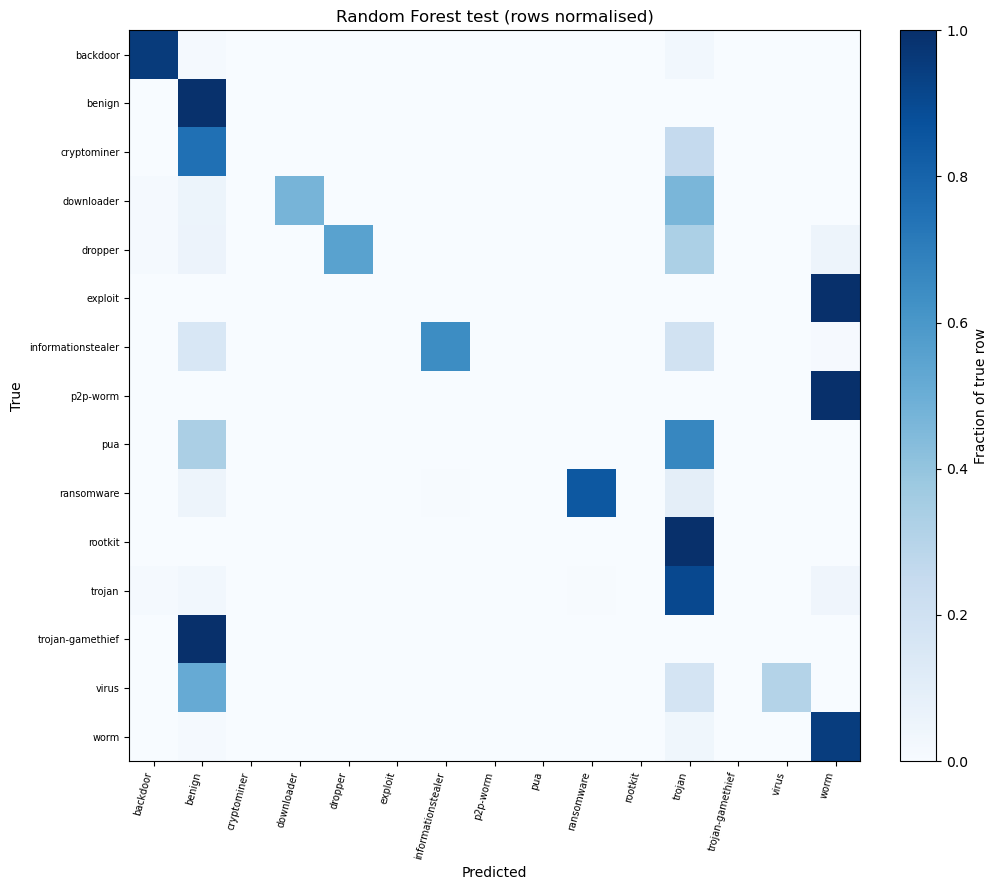

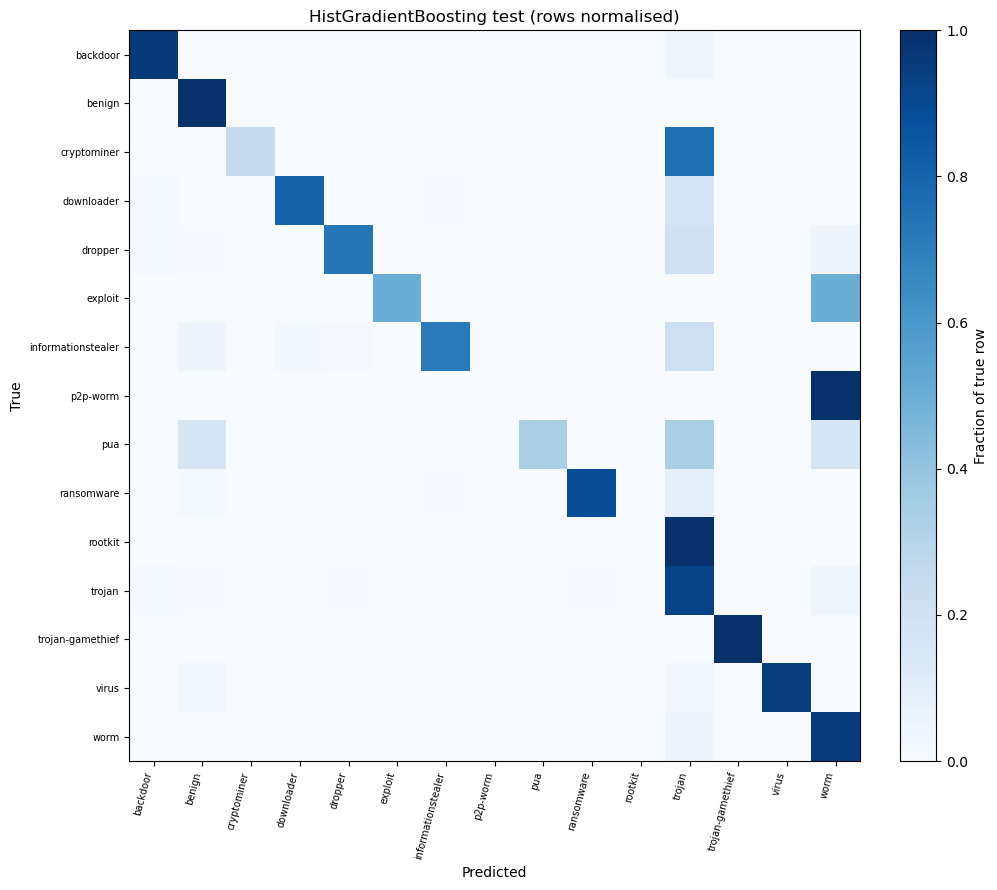

In [9]:
def plot_confusion_row_normalised(y_true, y_pred, class_names_list, title, save_path):
    lab_idx  = np.arange(len(class_names_list))
    cm       = confusion_matrix(y_true, y_pred, labels=lab_idx)
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = np.divide(
            cm, row_sums,
            out=np.zeros_like(cm, dtype=float),
            where=row_sums != 0,
        )
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    n = len(class_names_list)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(class_names_list, rotation=75, ha="right", fontsize=7)
    ax.set_yticklabels(class_names_list, fontsize=7)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Fraction of true row")
    plt.tight_layout()
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


plot_confusion_row_normalised(
    y_test, rf_test_pred, class_names,
    "Random Forest test (rows normalised)",
    "artifacts/cm_rf_test.png",
)
plot_confusion_row_normalised(
    y_test, hgb_test_pred, class_names,
    "HistGradientBoosting test (rows normalised)",
    "artifacts/cm_hgb_test.png",
)

## 11. Side-by-side summary and save artifacts

In [10]:
summary = pd.DataFrame({
    "Model":          ["Random Forest", "HistGradientBoosting"],
    "Test accuracy":  [rf_test_acc,  hgb_test_acc],
    "Train accuracy": [rf_train_acc, hgb_train_acc],
})
print(summary.to_string(index=False))

compare = pd.DataFrame({
    "class":   class_names,
    "RF_TPR":  rf_test_df["TPR (recall)"].values,
    "RF_FPR":  rf_test_df["FPR"].values,
    "HGB_TPR": hgb_test_df["TPR (recall)"].values,
    "HGB_FPR": hgb_test_df["FPR"].values,
})
print("\nPer-class TPR/FPR on test:")
print(compare.to_string(index=False))

out_dir = Path("artifacts")
out_dir.mkdir(exist_ok=True)

summary.to_csv(out_dir / "test_summary.csv", index=False)
compare.to_csv(out_dir / "per_class_metrics_test.csv", index=False)
joblib.dump(rf_model,          out_dir / "random_forest.joblib")
joblib.dump(hgb_model,         out_dir / "hist_gradient_boosting.joblib")
joblib.dump(le,                out_dir / "label_encoder.joblib")
joblib.dump(imputer,           out_dir / "median_imputer.joblib")
joblib.dump(variance_selector, out_dir / "variance_threshold.joblib")

with open(out_dir / "best_params.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "random_forest":          rf_search.best_params_,
            "hist_gradient_boosting": best_hgb_params,
        },
        f, indent=2, default=str,
    )

print("Artifacts saved to", out_dir.resolve())

               Model  Test accuracy  Train accuracy
       Random Forest       0.957303        0.959097
HistGradientBoosting       0.968758        0.978586

Per-class TPR/FPR on test:
             class   RF_TPR   RF_FPR  HGB_TPR  HGB_FPR
          backdoor 0.956344 0.003934 0.961119 0.003894
            benign 0.996046 0.027140 0.997926 0.005934
       cryptominer 0.000000 0.000000 0.250000 0.000000
        downloader 0.470874 0.000450 0.805825 0.000750
           dropper 0.552448 0.000561 0.727273 0.001383
           exploit 0.000000 0.000000 0.500000 0.000000
informationstealer 0.644444 0.000187 0.711111 0.000373
          p2p-worm 0.000000 0.000000 0.000000 0.000037
               pua 0.000000 0.000000 0.333333 0.000000
        ransomware 0.847561 0.001123 0.890244 0.001123
           rootkit 0.000000 0.000000 0.000000 0.000000
            trojan 0.904587 0.019720 0.924103 0.015652
  trojan-gamethief 0.000000 0.000000 1.000000 0.000000
             virus 0.307692 0.000000 0.948718 

## 12. Notes for the PDF report

1. **Team roles** — who did data prep, modelling, writing.
2. **Algorithms** — expand Section 7 into cited prose; contrast bagging vs boosting.
3. **Preprocessing** — row alignment; benign/malware merge on SHA-256; median imputer
   + variance filter fit on train only; no scaling for tree models.
4. **Train/test** — stratified split, test_size=0.2, random_state=42; test used once.
5. **Hyperparameters** — RandomizedSearchCV with f1_macro on a stratified subsample;
   HGB uses fixed params with early_stopping=False.
6. **Evaluation** — overall accuracy; per-class TPR/FPR (one-vs-rest); compare models.
7. Include confusion matrix figures from artifacts/ with captions.